<a href="https://colab.research.google.com/github/sumathimuneeswaran06/loan-approval-prediction/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Approval Prediction System**

Mounted at /content/drive
Random Forest Accuracy: 0.8225
Logistic Regression Accuracy: 0.8425
SVM Accuracy: 0.839


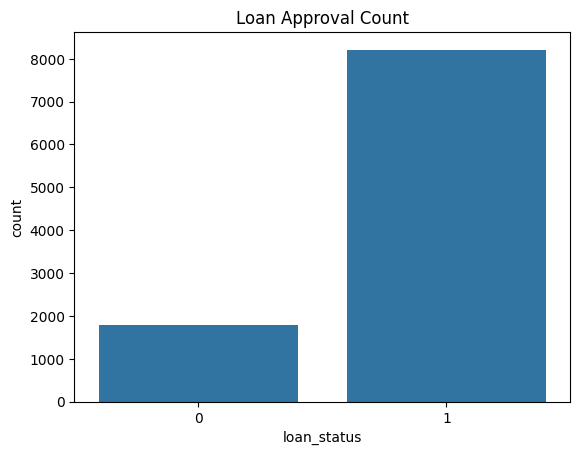

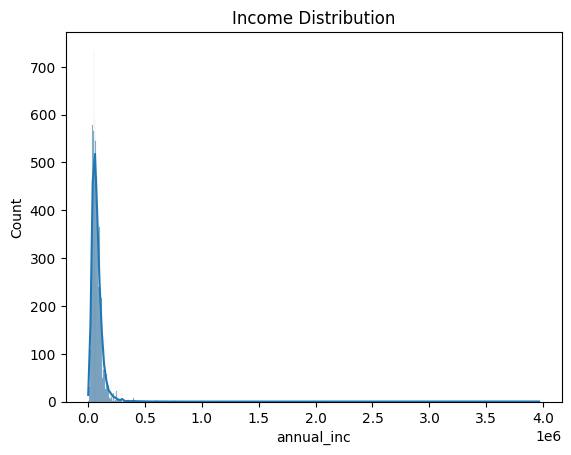

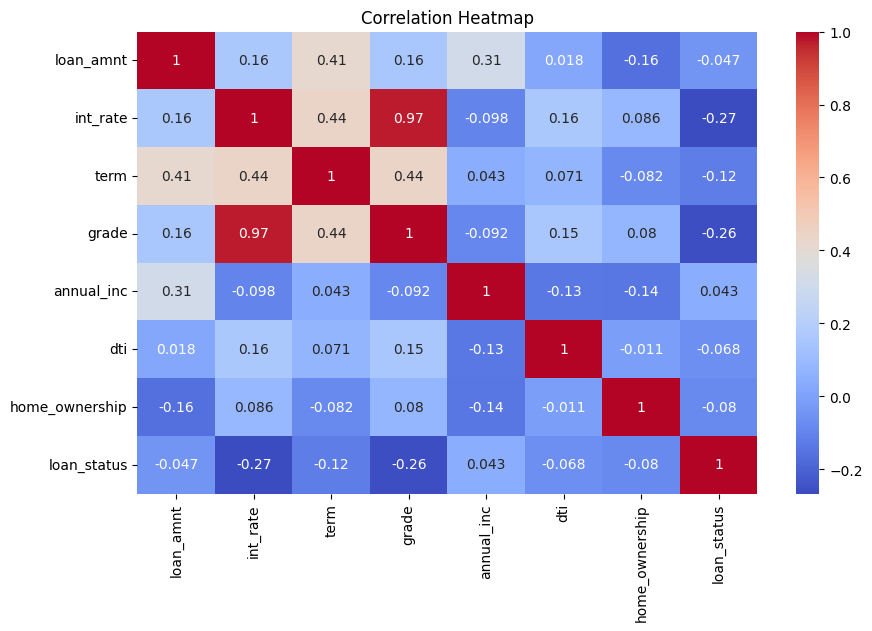

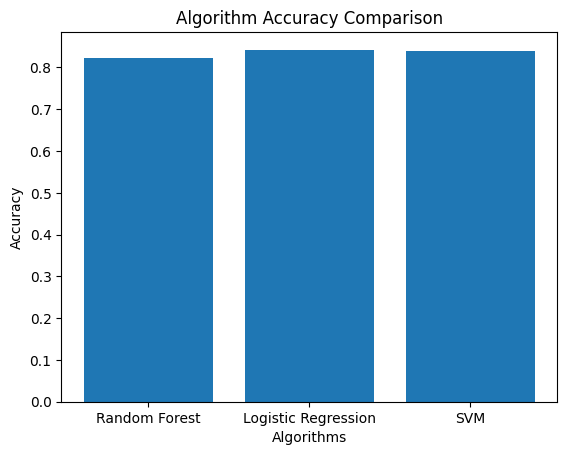


Enter Applicant Details 👇
Enter Age: 20
Enter Loan Amount: 200000
Enter Interest Rate (%): 12.5
Enter Term (36 or 60): 60
Enter Grade (0-6): 0
Enter Annual Income: 100000
Enter Debt-to-Income Ratio: 10
Enter Home Ownership (0-3): 0

--- RESULT ---
Age 20: Loan Approved ✅


In [1]:
# 🔷 1. Mount Google Drive (run once)
from google.colab import drive
drive.mount('/content/drive')

# 🔷 2. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 🔷 3. Load Dataset
df = pd.read_csv("/content/drive/MyDrive/accepted_2007_to_2018Q4.csv",
                 nrows=10000, low_memory=False)

# 🔷 4. Select Required Columns
df = df[['loan_amnt','int_rate','term','grade',
         'annual_inc','dti','home_ownership','loan_status']]

# 🔷 5. Handle Missing Values
df = df.ffill()

# 🔷 6. Fix Interest Rate
df['int_rate'] = df['int_rate'].astype(str).str.replace('%','', regex=False).astype(float)

# 🔷 7. Convert Loan Status to Binary
df['loan_status'] = df['loan_status'].apply(
    lambda x: 1 if x in ['Fully Paid', 'Current'] else 0
)

# 🔷 8. Encode Categorical Data
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# 🔷 9. Split Input & Output
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 🔷 10. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# 🤖 11. Random Forest
# =====================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

# =====================================
# 🤖 12. Logistic Regression
# =====================================
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

# =====================================
# 🤖 13. SVM
# =====================================
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

# =====================================
# 📊 14. Graphs
# =====================================

sns.countplot(x='loan_status', data=df)
plt.title("Loan Approval Count")
plt.show()

sns.histplot(df['annual_inc'], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# =====================================
# 📊 15. Accuracy Comparison Graph
# =====================================
models = ['Random Forest', 'Logistic Regression', 'SVM']
accuracy = [rf_acc, log_acc, svm_acc]

plt.bar(models, accuracy)
plt.title("Algorithm Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.show()

# =====================================
# 🎯 16. USER INPUT PREDICTION
# =====================================

print("\nEnter Applicant Details 👇")

# Age (extra input, not used in model)
age = int(input("Enter Age: "))

loan_amnt = float(input("Enter Loan Amount: "))
int_rate = float(input("Enter Interest Rate (%): "))
term = int(input("Enter Term (36 or 60): "))
grade = int(input("Enter Grade (0-6): "))
annual_inc = float(input("Enter Annual Income: "))
dti = float(input("Enter Debt-to-Income Ratio: "))
home_ownership = int(input("Enter Home Ownership (0-3): "))


# Prepare input
new_data = [[loan_amnt, int_rate, term, grade, annual_inc, dti, home_ownership]]

new_df = pd.DataFrame(new_data, columns=X.columns)

# Prediction using best model
result = rf_model.predict(new_df)

print("\n--- RESULT ---")

if result[0] == 1:
    print(f"Age {age}: Loan Approved ✅")
else:
    print(f"Age {age}: Loan Not Approved ❌")